In [1]:
import sys
sys.path.append('src')
from black_scholes import *


Fetching data for TSLA...
Risk-free rate (13-week T-Bill) : 3.58%

══════════════════════════════════════════════════
  TSLA — Black-Scholes Analysis
══════════════════════════════════════════════════
  Current price    : $404.11
  Strike (5% OTM)  : $424
  Expiry           : 2026-08-21  (94 days)
  Risk-free rate   : 3.6%
  30d realised vol : 41.5%  ← your forecast
  60d realised vol : 40.9%
  252d realised vol: 47.0%  ← market proxy

──────────────────────────────────────────────────
  Pricing — $424 Strike
──────────────────────────────────────────────────
  Market call price  : $31.6247
  Your call price    : $27.1677
  Market put price   : $47.6289
  Your put price     : $43.1719
  Edge per contract  : $-4.4569

  ► SELL the call — market overpricing vol

──────────────────────────────────────────────────
  Greeks — $424 Call
──────────────────────────────────────────────────
  Delta : 0.4826  → option moves $0.48 per $1 in TSLA
  Gamma : 0.004136
  Theta : -80.4071  → loses $80.

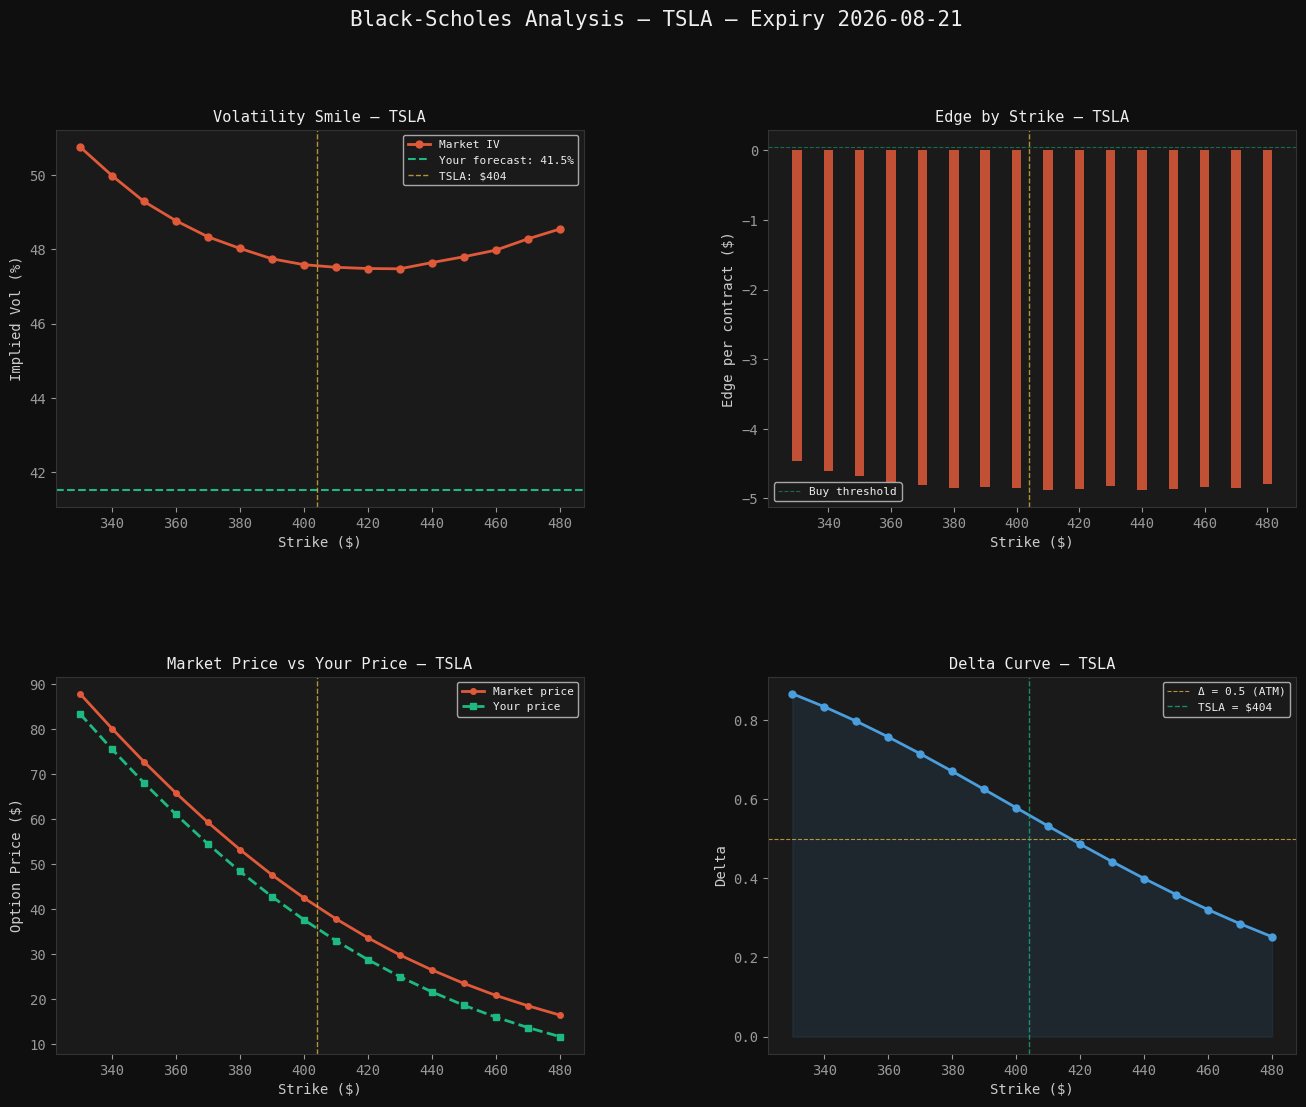


══════════════════════════════════════════════════
  Analysis complete — TSLA
  Your forecast vol  : 41.5%
  Best edge strike   : $330
  Max edge           : $-4.4651 per contract
══════════════════════════════════════════════════


In [5]:
# ════════════════════════════════════════════════
# BLACK-SCHOLES PRICER — Interactive Version
# ════════════════════════════════════════════════

import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf

# ── User inputs ──────────────────────────────────
TICKER      = input("Enter stock ticker (e.g. AAPL, TSLA, NVDA) : ").upper().strip()
TARGET_DAYS = int(input("Days to expiry (e.g. 90)                   : "))
# ─────────────────────────────────────────────────

print(f"\nFetching data for {TICKER}...")

# ── Fetch stock data ─────────────────────────────
stock = yf.Ticker(TICKER)
hist  = stock.history(period="2y")

# Fetch current 13-week T-Bill rate automatically
tbill = yf.Ticker("^IRX")
R     = tbill.history(period="5d")["Close"].iloc[-1] / 100

print(f"Risk-free rate (13-week T-Bill) : {R*100:.2f}%")

if hist.empty:
    print(f"Could not find ticker '{TICKER}'. Please check the symbol and try again.")
else:
    # Current price
    S = hist["Close"].iloc[-1]

    # Log returns and volatility
    log_returns = np.log(hist["Close"] / hist["Close"].shift(1)).dropna()
    vol_30d     = log_returns[-30:].std()  * np.sqrt(252)
    vol_60d     = log_returns[-60:].std()  * np.sqrt(252)
    vol_252d    = log_returns[-252:].std() * np.sqrt(252)

    YOUR_FORECAST_VOL  = vol_30d
    MARKET_IMPLIED_VOL = vol_252d

    # ── Find closest expiry ───────────────────────
    TODAY       = datetime.date.today()
    target_date = TODAY + datetime.timedelta(days=TARGET_DAYS)

    best_expiry = min(
        stock.options,
        key=lambda x: abs(
            datetime.datetime.strptime(x, '%Y-%m-%d').date() - target_date
        )
    )
    T_real = (datetime.datetime.strptime(best_expiry, '%Y-%m-%d').date() - TODAY).days / 365
    K      = round(S * 1.05, 0)

    # ── Summary ───────────────────────────────────
    print(f"\n{'═'*50}")
    print(f"  {TICKER} — Black-Scholes Analysis")
    print(f"{'═'*50}")
    print(f"  Current price    : ${S:.2f}")
    print(f"  Strike (5% OTM)  : ${K:.0f}")
    print(f"  Expiry           : {best_expiry}  ({T_real*365:.0f} days)")
    print(f"  Risk-free rate   : {R*100:.1f}%")
    print(f"  30d realised vol : {vol_30d*100:.1f}%  ← your forecast")
    print(f"  60d realised vol : {vol_60d*100:.1f}%")
    print(f"  252d realised vol: {vol_252d*100:.1f}%  ← market proxy")

    # ── Option pricing ────────────────────────────
    mkt_call  = call_price(S, K, T_real, R, MARKET_IMPLIED_VOL)
    your_call = call_price(S, K, T_real, R, YOUR_FORECAST_VOL)
    mkt_put   = put_price(S, K, T_real, R, MARKET_IMPLIED_VOL)
    your_put  = put_price(S, K, T_real, R, YOUR_FORECAST_VOL)
    edge      = your_call - mkt_call

    print(f"\n{'─'*50}")
    print(f"  Pricing — ${K:.0f} Strike")
    print(f"{'─'*50}")
    print(f"  Market call price  : ${mkt_call:.4f}")
    print(f"  Your call price    : ${your_call:.4f}")
    print(f"  Market put price   : ${mkt_put:.4f}")
    print(f"  Your put price     : ${your_put:.4f}")
    print(f"  Edge per contract  : ${edge:+.4f}")

    if edge > 0.05:
        print(f"\n  ► BUY the call — market underpricing vol")
    elif edge < -0.05:
        print(f"\n  ► SELL the call — market overpricing vol")
    else:
        print(f"\n  ► No clear edge — fairly priced")

    # ── Greeks ────────────────────────────────────
    print(f"\n{'─'*50}")
    print(f"  Greeks — ${K:.0f} Call")
    print(f"{'─'*50}")
    print(f"  Delta : {delta(S, K, T_real, R, MARKET_IMPLIED_VOL):.4f}  → option moves ${delta(S, K, T_real, R, MARKET_IMPLIED_VOL):.2f} per $1 in {TICKER}")
    print(f"  Gamma : {gamma(S, K, T_real, R, MARKET_IMPLIED_VOL):.6f}")
    print(f"  Theta : {theta(S, K, T_real, R, MARKET_IMPLIED_VOL):.4f}  → loses ${abs(theta(S, K, T_real, R, MARKET_IMPLIED_VOL)):.4f} per day")
    print(f"  Vega  : {vega(S, K, T_real, R, MARKET_IMPLIED_VOL):.4f}  → gains ${vega(S, K, T_real, R, MARKET_IMPLIED_VOL):.4f} per 1% vol rise")
    print(f"  Rho   : {rho(S, K, T_real, R, MARKET_IMPLIED_VOL):.4f}  → gains ${rho(S, K, T_real, R, MARKET_IMPLIED_VOL):.4f} per 1% rate rise")

    # ── Real options chain ────────────────────────
    chain_real  = stock.option_chain(best_expiry)
    calls_real  = chain_real.calls
    mask        = (calls_real['strike'] >= S * 0.80) & (calls_real['strike'] <= S * 1.20)
    calls_real  = calls_real[mask].copy()

    calls_real['mid_price']    = (calls_real['bid'] + calls_real['ask']) / 2
    calls_real['implied_vol']  = calls_real.apply(
        lambda row: implied_volatility(row['mid_price'], S, row['strike'], T_real, R, 'call'),
        axis=1
    )
    calls_real['forecast_vol'] = YOUR_FORECAST_VOL
    calls_real['vol_diff']     = (calls_real['forecast_vol'] - calls_real['implied_vol']).round(4)
    calls_real['edge']         = calls_real.apply(
        lambda row: round(
            call_price(S, row['strike'], T_real, R, YOUR_FORECAST_VOL) -
            call_price(S, row['strike'], T_real, R, row['implied_vol']), 4
        ) if not np.isnan(row['implied_vol']) else np.nan, axis=1
    )
    calls_real['signal'] = calls_real['edge'].apply(
        lambda e: "BUY ▲" if e > 0.05 else ("SELL ▼" if e < -0.05 else "—")
        if not np.isnan(e) else "—"
    )

    print(f"\n{'─'*50}")
    print(f"  Real Options Chain — {TICKER} — {best_expiry}")
    print(f"{'─'*50}")
    print(calls_real[['strike','mid_price','implied_vol','vol_diff','edge','signal']].to_string(index=False))

    # ── Visualisations ────────────────────────────
    plot_data = calls_real.dropna(subset=['implied_vol','edge'])

    plt.rcParams.update({
        "figure.facecolor" : "#0f0f0f",
        "axes.facecolor"   : "#1a1a1a",
        "axes.edgecolor"   : "#333333",
        "axes.labelcolor"  : "#cccccc",
        "xtick.color"      : "#999999",
        "ytick.color"      : "#999999",
        "text.color"       : "#eeeeee",
        "grid.color"       : "#2a2a2a",
        "grid.linewidth"   : 0.5,
        "font.family"      : "monospace",
    })

    TEAL   = "#1DB980"
    CORAL  = "#E05A3A"
    BLUE   = "#4A9EDD"
    YELLOW = "#F5C542"

    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(f"Black-Scholes Analysis — {TICKER} — Expiry {best_expiry}",
                 fontsize=15, y=0.98, color="#eeeeee")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Volatility smile
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(plot_data['strike'], plot_data['implied_vol'] * 100,
             color=CORAL, linewidth=2, marker='o', markersize=5, label='Market IV')
    ax1.axhline(YOUR_FORECAST_VOL * 100, color=TEAL, linestyle='--',
                linewidth=1.5, label=f'Your forecast: {YOUR_FORECAST_VOL*100:.1f}%')
    ax1.axvline(S, color=YELLOW, linestyle='--', linewidth=1,
                alpha=0.7, label=f'{TICKER}: ${S:.0f}')
    ax1.set_title(f'Volatility Smile — {TICKER}', fontsize=11)
    ax1.set_xlabel('Strike ($)')
    ax1.set_ylabel('Implied Vol (%)')
    ax1.legend(fontsize=8)

    # Edge by strike
    ax2 = fig.add_subplot(gs[0, 1])
    bar_colors = [TEAL if e > 0.05 else CORAL if e < -0.05 else "#888888"
                  for e in plot_data['edge']]
    ax2.bar(plot_data['strike'], plot_data['edge'],
            color=bar_colors, alpha=0.85, width=3)
    ax2.axhline(0.05, color=TEAL, linestyle='--',
                linewidth=0.8, alpha=0.5, label='Buy threshold')
    ax2.axvline(S, color=YELLOW, linestyle='--', linewidth=1, alpha=0.7)
    ax2.set_title(f'Edge by Strike — {TICKER}', fontsize=11)
    ax2.set_xlabel('Strike ($)')
    ax2.set_ylabel('Edge per contract ($)')
    ax2.legend(fontsize=8)

    # Market vs your price
    ax3 = fig.add_subplot(gs[1, 0])
    your_prices = plot_data['strike'].apply(
        lambda k: call_price(S, k, T_real, R, YOUR_FORECAST_VOL)
    )
    ax3.plot(plot_data['strike'], plot_data['mid_price'],
             color=CORAL, linewidth=2, marker='o', markersize=4, label='Market price')
    ax3.plot(plot_data['strike'], your_prices,
             color=TEAL, linewidth=2, linestyle='--',
             marker='s', markersize=4, label='Your price')
    ax3.axvline(S, color=YELLOW, linestyle='--', linewidth=1, alpha=0.7)
    ax3.set_title(f'Market Price vs Your Price — {TICKER}', fontsize=11)
    ax3.set_xlabel('Strike ($)')
    ax3.set_ylabel('Option Price ($)')
    ax3.legend(fontsize=8)

    # Delta curve
    ax4 = fig.add_subplot(gs[1, 1])
    plot_data['delta_val'] = plot_data['strike'].apply(
        lambda k: delta(S, k, T_real, R, YOUR_FORECAST_VOL)
    )
    ax4.plot(plot_data['strike'], plot_data['delta_val'],
             color=BLUE, linewidth=2, marker='o', markersize=5)
    ax4.axhline(0.5, color=YELLOW, linestyle='--',
                linewidth=0.8, alpha=0.7, label='Δ = 0.5 (ATM)')
    ax4.axvline(S, color=TEAL, linestyle='--',
                linewidth=1, alpha=0.7, label=f'{TICKER} = ${S:.0f}')
    ax4.fill_between(plot_data['strike'], plot_data['delta_val'],
                     alpha=0.1, color=BLUE)
    ax4.set_title(f'Delta Curve — {TICKER}', fontsize=11)
    ax4.set_xlabel('Strike ($)')
    ax4.set_ylabel('Delta')
    ax4.legend(fontsize=8)

    filename = f"{TICKER}_black_scholes_{TODAY}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
    print(f"\nChart saved → {filename}")
    plt.show()

    print(f"\n{'═'*50}")
    print(f"  Analysis complete — {TICKER}")
    print(f"  Your forecast vol  : {YOUR_FORECAST_VOL*100:.1f}%")
    print(f"  Best edge strike   : ${plot_data.loc[plot_data['edge'].idxmax(), 'strike']:.0f}")
    print(f"  Max edge           : ${plot_data['edge'].max():.4f} per contract")
    print(f"{'═'*50}")